<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum13/praktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas Praktikum Mandiri

Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi


Link Github:
1.   Praktikum di Kelas:
2.   Praktikum Mandiri:

### Import Library

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

Library torch digunakan sebagai pustaka utama untuk komputasi tensor dan deep learning. Modul torch.nn menyediakan komponen untuk membangun arsitektur neural network seperti layer dan fungsi aktivasi, sedangkan torch.optim digunakan untuk proses optimasi bobot model. Library torchvision.datasets dan transforms dimanfaatkan untuk memuat dataset MNIST serta melakukan preprocessing data. DataLoader digunakan untuk mengatur pembagian data ke dalam batch, sementara matplotlib dan numpy digunakan untuk keperluan visualisasi dan manipulasi data numerik.

### Load dan Persiapan Data

In [2]:
# parameter
batch_size = 64

# transform data
transform = transforms.ToTensor()

# load dataset MNIST
train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

# data loader
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


Parameter batch_size diatur sebesar 64 untuk menentukan jumlah data yang diproses dalam satu iterasi. Transformasi ToTensor() digunakan untuk mengubah citra MNIST menjadi tensor serta menormalisasi nilai piksel ke rentang 0–1. Dataset kemudian dibagi menjadi data training dan data testing, diunduh secara otomatis jika belum tersedia, dan dimuat menggunakan DataLoader. Data training diacak (shuffle=True) untuk meningkatkan generalisasi model, sedangkan data testing tidak diacak (shuffle=False) karena hanya digunakan untuk evaluasi.

### Visualisasi Data MNIST

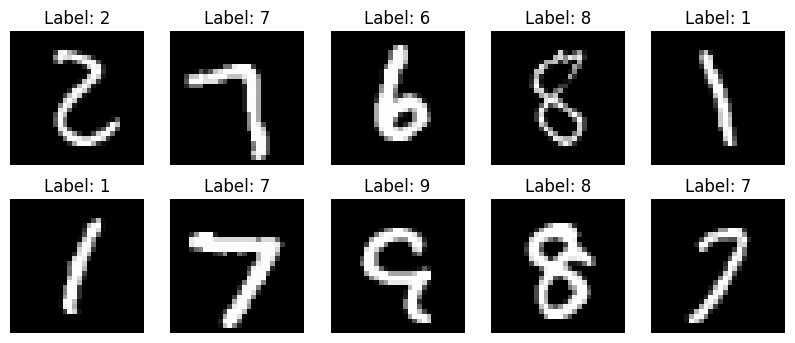

In [3]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

images = images.numpy()

fig = plt.figure(figsize=(10, 4))
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx+1)
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(f"Label: {labels[idx].item()}")
    ax.axis('off')

plt.show()

train_loader diubah menjadi iterator dan diambil satu batch data yang berisi gambar dan label. Data gambar kemudian dikonversi dari tensor PyTorch menjadi array NumPy agar dapat divisualisasikan. Selanjutnya dibuat sebuah figure dan ditampilkan 10 gambar pertama dalam bentuk grid 2×5 menggunakan skala abu-abu. Setiap gambar ditampilkan beserta label angka yang sesuai, sementara sumbu gambar disembunyikan agar tampilan lebih jelas.

### Arsitektur Model MLP

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Multi-Layer Perceptron (MLP) menggunakan PyTorch. Model terdiri dari tiga layer fully connected, yaitu layer input dengan 784 neuron hasil flatten citra MNIST berukuran 28×28, dua hidden layer dengan 128 dan 64 neuron, serta output layer dengan 10 neuron yang merepresentasikan kelas angka 0–9. Fungsi aktivasi ReLU digunakan pada setiap hidden layer untuk menangkap pola non-linear. Pada fungsi forward, data citra terlebih dahulu diubah menjadi vektor satu dimensi, kemudian diproses secara berurutan melalui setiap layer hingga menghasilkan output prediksi kelas.

### Inisialisasi Model, Loss, dan Optimizer

In [5]:
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = MLP() membuat instance dari arsitektur MLP yang telah didefinisikan. criterion = nn.CrossEntropyLoss() menetapkan fungsi loss untuk mengukur kesalahan prediksi pada klasifikasi multi-kelas. Sementara itu, optimizer = optim.Adam(model.parameters(), lr=0.001) digunakan untuk memperbarui bobot model secara adaptif dengan learning rate 0,001 selama proses training

### Proses Training Model

In [6]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/5], Loss: 0.3410
Epoch [2/5], Loss: 0.1419
Epoch [3/5], Loss: 0.0978
Epoch [4/5], Loss: 0.0754
Epoch [5/5], Loss: 0.0599


Kode tersebut merupakan proses **training model** yang dilakukan selama 5 epoch. Pada setiap epoch, model memproses seluruh data training secara bertahap per batch. Gradien dari iterasi sebelumnya dihapus, kemudian dilakukan forward pass untuk menghasilkan prediksi dan menghitung nilai loss. Selanjutnya dilakukan backpropagation dan pembaruan bobot menggunakan optimizer. Nilai loss dari setiap batch dijumlahkan dan dirata-ratakan untuk memantau perkembangan pelatihan pada setiap epoch.


Evaluasi Model

In [7]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Akurasi Model: {accuracy:.2f}%")

Akurasi Model: 97.39%


Model menghasilkan prediksi kelas untuk setiap data, kemudian prediksi tersebut dibandingkan dengan label sebenarnya untuk menghitung jumlah prediksi yang benar. Akurasi model diperoleh dari persentase prediksi yang benar terhadap total data uji dan ditampilkan sebagai hasil evaluasi